# **Setup**

In [1]:
%pip install numpy matplotlib pillow tensorflow

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

# **Dataset Selection**

The selected dataset is ideal for Convolutional Neural Networks (CNNs) because distinguishing between white blood cell types relies on detecting local visual patterns rather than fixed geometric positions.

1.  **Texture & Shape Recognition:** Classes are defined by specific textures (cytoplasm granules) and shapes (nucleus lobes vs. round nuclei). CNN filters are designed to automatically learn these edge and texture features.
2.  **Spatial Invariance:** The white blood cell of interest may appear anywhere in the image. CNNs use weight sharing (sliding windows) to detect these features regardless of the cell's location in the frame.

# **Part 1. Dataset Exploration**

In [3]:
base_path = "."
train_search = glob.glob(os.path.join(base_path, "**", "TRAIN"), recursive=True)

if train_search:
    train_path = train_search[0]
    print(f"Found dataset at: {train_path}")

    test_path = train_path.replace("TRAIN", "TEST")
else:
    print("Error: Could not find a 'TRAIN' folder. Please check your folder structure.")

Found dataset at: ./dataset2-master/dataset2-master/images/TRAIN


In [4]:
classes = os.listdir(train_path)
class_counts = {}

print("--- Class Distribution (Training Set) ---")
for class_name in classes:
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        images = os.listdir(class_dir)
        count = len([f for f in images if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = count
        print(f"• {class_name}: {count} images")

counts = list(class_counts.values())
if max(counts) - min(counts) < 200:
    print("\nStatus: The dataset is BALANCED.")
else:
    print("\nStatus: The dataset is IMBALANCED.")

--- Class Distribution (Training Set) ---
• NEUTROPHIL: 2499 images
• MONOCYTE: 2478 images
• EOSINOPHIL: 2497 images
• LYMPHOCYTE: 2483 images

Status: The dataset is BALANCED.


In [5]:
first_class = list(class_counts.keys())[0]
first_img_path = os.path.join(train_path, first_class, os.listdir(os.path.join(train_path, first_class))[0])

with Image.open(first_img_path) as img:
    img_array = np.array(img)
    
    print("--- Image Technical Specs ---")
    print(f"Original Size: {img.size} (Width x Height)")
    print(f"Color Mode:    {img.mode} (RGB means 3 color channels)")
    print(f"Tensor Shape:  {img_array.shape} (Height, Width, Channels)")
    print(f"Pixel Range:   {img_array.min()} to {img_array.max()}")

--- Image Technical Specs ---
Original Size: (320, 240) (Width x Height)
Color Mode:    RGB (RGB means 3 color channels)
Tensor Shape:  (240, 320, 3) (Height, Width, Channels)
Pixel Range:   0 to 252


### **Visualizing Samples**

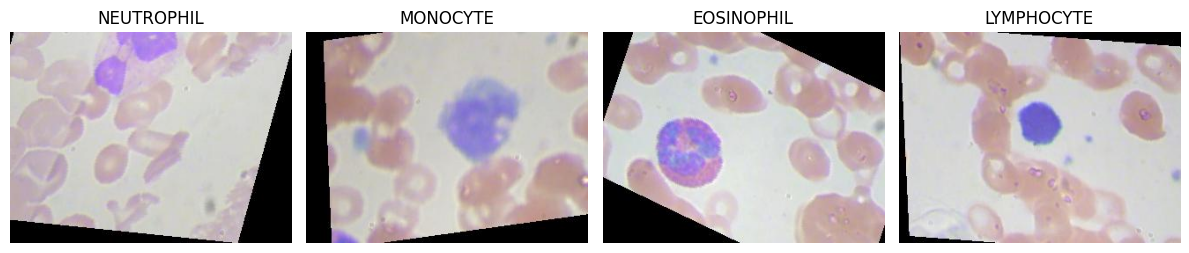

In [6]:
plt.figure(figsize=(12, 4))

for i, class_name in enumerate(class_counts.keys()):
    class_folder = os.path.join(train_path, class_name)

    img_file = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
    img_full_path = os.path.join(class_folder, img_file)

    img = Image.open(img_full_path)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Preprocessing Analysis**

In [7]:
print("\n--- Preprocessing Requirements ---")
if img_array.max() > 1:
    print("Normalization Needed: Yes (Pixel values are 0-255 -> Scale to 0-1)")
else:
    print("Normalization Needed: No (Already 0-1)")

if img.size != (128, 128) and img.size != (224, 224):
    print(f"Resizing Needed:      Yes (Current size {img.size} -> Resize to 128x128 or 224x224 for CNN)")
else:
    print("Resizing Needed:      No")


--- Preprocessing Requirements ---
Normalization Needed: Yes (Pixel values are 0-255 -> Scale to 0-1)
Resizing Needed:      Yes (Current size (320, 240) -> Resize to 128x128 or 224x224 for CNN)


#### Preprocessing needed

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

print(f"Dataset Path: {train_path}")

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\n--- Pipeline Status ---")
print(f"Classes Found: {list(train_generator.class_indices.keys())}")
print(f"Image Shape:   {train_generator.image_shape}")

/Users/juanleal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Dataset Path: ./dataset2-master/dataset2-master/images/TRAIN
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.

--- Pipeline Status ---
Classes Found: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Image Shape:   (128, 128, 3)


# **Part 2. Dataset Baseline Model**

### **Creating the Non-Convolutional model**

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

baseline_model = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Baseline Model Summary ---")
baseline_model.summary()

--- Baseline Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,292,100 (24.00 MB)

 Trainable params: 6,292,100 (24.00 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_baseline = baseline_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/10


/Users/juanleal/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2508 - loss: 10.9227 - val_accuracy: 0.2795 - val_loss: 4.1473
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2775 - loss: 2.8041 - val_accuracy: 0.2634 - val_loss: 1.7611
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2894 - loss: 1.8043 - val_accuracy: 0.2514 - val_loss: 2.0254
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3086 - loss: 1.5481 - val_accuracy: 0.2790 - val_loss: 1.5420
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3089 - loss: 1.5196 - val_accuracy: 0.2509 - val_loss: 1.3863
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2574 - loss: 1.3862 - val_accuracy: 0.2509 - val_loss: 1.3863
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2467 - loss: 1.3864 - val_accuracy: 0.2509 - val_loss: 1.3863
Epoch 8/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2532 - loss: 1.3864 - val_accuracy: 0.25

#### Visualization of Results

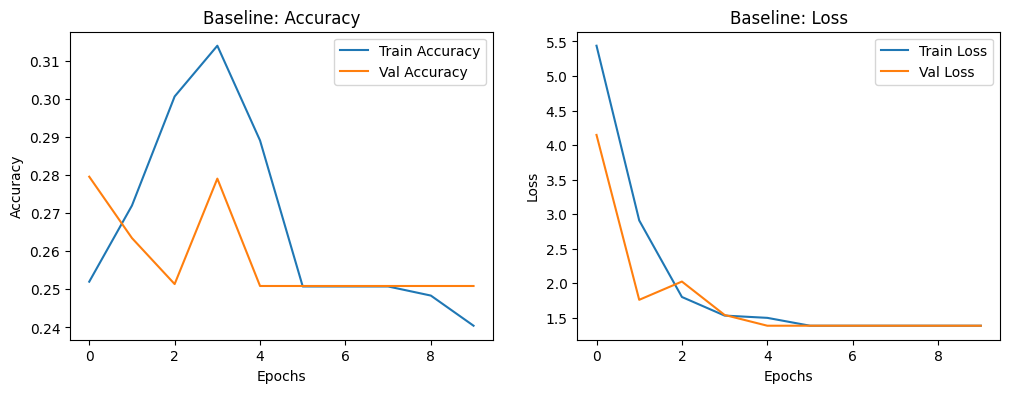


--- Observed Limitations (for your report) ---
1. OVERFITTING: You will likely see Training Accuracy go high (e.g., 90%) but Validation Accuracy get stuck or drop (e.g., 50-60%).
   - Why? The model memorizes exact pixel values instead of learning patterns.
2. PARAMETER EXPLOSION: The model has 6,292,100 parameters.
   - This is inefficient. A CNN would use far fewer parameters to achieve better results.
3. SPATIAL LOSS: The Flatten layer destroyed the shape of the cells. The model doesn't know that pixel (0,0) is next to pixel (0,1).


In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

print("\n--- Observed Limitations (for your report) ---")
print("1. OVERFITTING: You will likely see Training Accuracy go high (e.g., 90%) but Validation Accuracy get stuck or drop (e.g., 50-60%).")
print("   - Why? The model memorizes exact pixel values instead of learning patterns.")
print(f"2. PARAMETER EXPLOSION: The model has {baseline_model.count_params():,} parameters.")
print("   - This is inefficient. A CNN would use far fewer parameters to achieve better results.")
print("3. SPATIAL LOSS: The Flatten layer destroyed the shape of the cells. The model doesn't know that pixel (0,0) is next to pixel (0,1).")

# **Part 3. Convolutional Architecture Design**

In [12]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

cnn_model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), 

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- CNN Summary ---")
cnn_model.summary()

--- CNN Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,052 (4.92 MB)

 Trainable params: 1,290,052 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

# **Part 4. Controlled Experiments of the Convolutional Layers**

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_experiment_model(kernel_size):
    model = Sequential([
        Input(shape=(128, 128, 3)),

        Conv2D(32, kernel_size, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, kernel_size, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, kernel_size, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        # Block 4
        Conv2D(128, kernel_size, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### **Experiments**

In [23]:
print("--- Experiment Start: Kernel Size Comparison ---")

print("\nTraining Model A (Kernel 3x3)...")
model_3x3 = create_experiment_model((3, 3))
history_3x3 = model_3x3.fit(
    train_generator,
    epochs=3,
    validation_data=validation_generator,
    verbose=1
)

print("\nTraining Model B (Kernel 7x7)...")
model_7x7 = create_experiment_model((7, 7))
history_7x7 = model_7x7.fit(
    train_generator,
    epochs=3,
    validation_data=validation_generator,
    verbose=1
)

--- Experiment Start: Kernel Size Comparison ---

Training Model A (Kernel 3x3)...
Epoch 1/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 47s 185ms/step - accuracy: 0.2793 - loss: 1.6654 - val_accuracy: 0.2539 - val_loss: 2.0770
Epoch 2/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 47s 191ms/step - accuracy: 0.3569 - loss: 1.3193 - val_accuracy: 0.2866 - val_loss: 1.6631
Epoch 3/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 48s 191ms/step - accuracy: 0.5374 - loss: 1.0338 - val_accuracy: 0.5711 - val_loss: 0.9393

Training Model B (Kernel 7x7)...
Epoch 1/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 181s 723ms/step - accuracy: 0.2869 - loss: 1.6512 - val_accuracy: 0.2720 - val_loss: 2.7040
Epoch 2/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 177s 711ms/step - accuracy: 0.4405 - loss: 1.1750 - val_accuracy: 0.2489 - val_loss: 12.7290
Epoch 3/3
249/249 ━━━━━━━━━━━━━━━━━━━━ 183s 734ms/step - accuracy: 0.6529 - loss: 0.7778 - val_accuracy: 0.3308 - val_loss: 5.3256


### **Comparison**

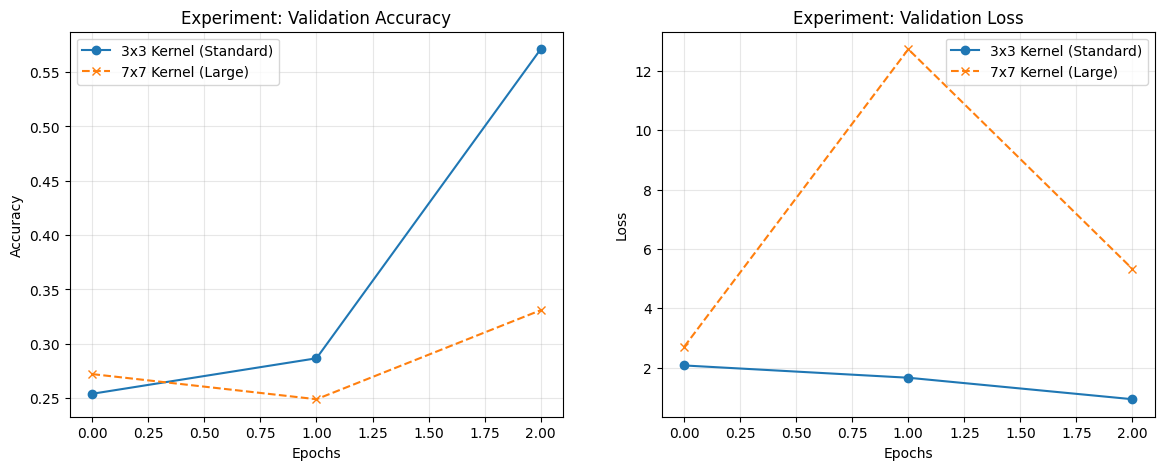

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_3x3.history['val_accuracy'], label='3x3 Kernel (Standard)', marker='o')
plt.plot(history_7x7.history['val_accuracy'], label='7x7 Kernel (Large)', marker='x', linestyle='--')
plt.title('Experiment: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_3x3.history['val_loss'], label='3x3 Kernel (Standard)', marker='o')
plt.plot(history_7x7.history['val_loss'], label='7x7 Kernel (Large)', marker='x', linestyle='--')
plt.title('Experiment: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [25]:
print("--- Complexity Analysis ---")
print(f"Model A (3x3) Parameters: {model_3x3.count_params():,}")
print(f"Model B (7x7) Parameters: {model_7x7.count_params():,}")

diff = model_7x7.count_params() - model_3x3.count_params()
print(f"Difference: The 7x7 model has {diff:,} more parameters.")

--- Complexity Analysis ---
Model A (3x3) Parameters: 1,291,460
Model B (7x7) Parameters: 2,360,260
Difference: The 7x7 model has 1,068,800 more parameters.
